In [1]:
import os
import shutil
import subprocess

os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

import autokeras as ak
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)


I0000 00:00:1779499736.966020  274492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779499737.007133  274492 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779499737.947525  274492 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Patch for AutoKeras + Keras 3（head.shape 可能含 numpy.int64）
# 僅套用一次；重複執行此格不會堆疊。若先前已重複執行過，請 Restart Kernel 再 Run All。
import autokeras.blocks.heads as _heads

if getattr(_heads, "_CLASSIFICATION_HEAD_BUILD_PATCHED", False):
    print("Patch already applied, skipping")
else:
    _orig_classification_head_build = _heads.ClassificationHead.build

    def _patched_build(self, hp, inputs=None):
        shape = self.__dict__.get("shape")
        if shape is not None:
            self.__dict__["shape"] = tuple(int(x) for x in shape)
        return _orig_classification_head_build(self, hp, inputs)

    _heads.ClassificationHead.build = _patched_build
    _heads._CLASSIFICATION_HEAD_BUILD_PATCHED = True
    print("Patch applied successfully")


Patch applied successfully


In [3]:
# Keras Tuner 搜尋需要 tensorboard
import tensorboard  # noqa: F401

PROJECT_DIR = "cifar10"

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


# AutoKeras 的 Normalization.adapt 會一次把訓練集搬到 GPU；
# 50000×32×32×3 約 586 MiB，在已占用的 Jupyter GPU 池裡常 OOM。
N_TRAIN_FIT = 50000

def release_gpu_memory():
    tf.keras.backend.clear_session()
    import gc

    gc.collect()


def reset_autokeras_project():
    """刪除先前失敗的 trial，避免 evaluate 讀到不完整的 checkpoint。"""
    if os.path.isdir(PROJECT_DIR):
        shutil.rmtree(PROJECT_DIR)
        print(f"已刪除舊專案: {PROJECT_DIR}")

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 已是 (N, 32, 32, 3)，勿 expand_dims
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("x_train:", x_train.shape, "x_test:", x_test.shape)

rng = np.random.default_rng(42)
fit_idx = rng.choice(len(x_train), N_TRAIN_FIT, replace=False)
print(f"AutoKeras fit 使用 {N_TRAIN_FIT} 筆子集，evaluate/predict 仍用完整測試集")


x_train: (50000, 32, 32, 3) x_test: (10000, 32, 32, 3)
AutoKeras fit 使用 50000 筆子集，evaluate/predict 仍用完整測試集


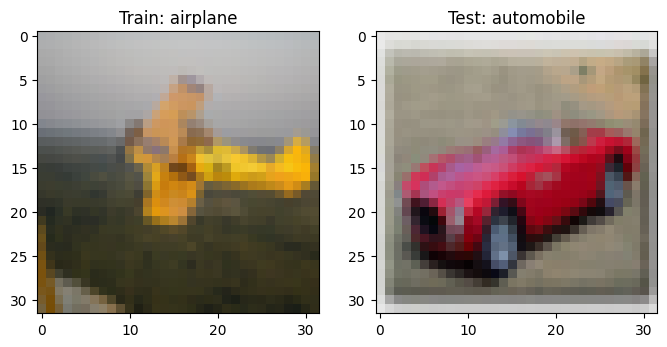

In [5]:
idx = 1234

fig = plt.figure(figsize=(8, 4))

ax = fig.add_subplot(1, 2, 1)
plt.imshow(x_train[idx])
ax.set_title(f"Train: {CLASS_NAMES[y_train[idx][0]]}")

ax = fig.add_subplot(1, 2, 2)
plt.imshow(x_test[idx])
ax.set_title(f"Test: {CLASS_NAMES[y_test[idx][0]]}")

plt.show()

In [6]:
release_gpu_memory()
reset_autokeras_project()
clf = ak.ImageClassifier(
    max_trials=5,
    project_name=PROJECT_DIR,
    overwrite=True,
)

已刪除舊專案: cifar10


In [ ]:
history = clf.fit(
    x_train[fit_idx],
    y_train[fit_idx],
    batch_size=16,
    epochs=20,
)
history

Trial 1 Complete [00h 02m 16s]
val_loss: 0.8779172897338867

Best val_loss So Far: 0.8779172897338867
Total elapsed time: 00h 02m 16s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
resnet            |vanilla           |image_block_1/block_type
True              |True              |image_block_1/normalize
True              |False             |image_block_1/augment
True              |None              |image_block_1/image_augmentation_1/horizontal_flip
True              |None              |image_block_1/image_augmentation_1/vertical_flip
0                 |None              |image_block_1/image_augmentation_1/contrast_factor
0                 |None              |image_block_1/image_augmentation_1/rotation_factor
0.1               |None              |image_block_1/image_augmentation_1/translation_factor
0                 |None              |image_block_1/image_augmentation_1/zoom_factor
False             |None              |image_block_1/res_net_block_1/pr

Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 191s 69ms/step - accuracy: 0.2701 - loss: 1.9946 - val_accuracy: 0.3331 - val_loss: 1.7811
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 172s 69ms/step - accuracy: 0.3778 - loss: 1.7018 - val_accuracy: 0.3508 - val_loss: 1.9720
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 164s 66ms/step - accuracy: 0.4496 - loss: 1.5167 - val_accuracy: 0.3644 - val_loss: 3.8031
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 166s 66ms/step - accuracy: 0.5264 - loss: 1.3173 - val_accuracy: 0.5724 - val_loss: 1.1945
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 164s 66ms/step - accuracy: 0.5846 - loss: 1.1601 - val_accuracy: 0.5808 - val_loss: 1.2025
Epoch 6/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 165s 66ms/step - accuracy: 0.6367 - loss: 1.0251 - val_accuracy: 0.6490 - val_loss: 0.9963
Epoch 7/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 165s 66ms/step - accuracy: 0.6606 - loss: 0.9576 - val_accuracy: 0.6915 - val_loss: 0.8842
Epoch 8/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 166s 66ms/step - accuracy: 

In [ ]:
clf.evaluate(x_test ,y_test ,batch_size=32)

/home/albert/AI_Class/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7068 - loss: 0.8688


[0.868811845779419, 0.7067999839782715]

In [ ]:
predicted = clf.predict(x_test ,batch_size=32)
predicted

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([['3'],
       ['8'],
       ['8'],
       ...,
       ['3'],
       ['4'],
       ['7']], shape=(10000, 1), dtype='<U1')

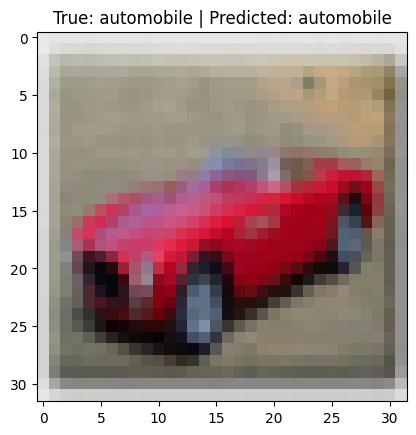

In [ ]:
idx = 1234
true_label = CLASS_NAMES[y_test[idx][0]]
pred_label = CLASS_NAMES[int(predicted[idx][0])]

plt.imshow(x_test[idx])
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.show()

In [ ]:
model = clf.export_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 3)      │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       125,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1 (Softmax) │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,849 (565.82 KB)

 Trainable params: 144,842 (565.79 KB)

 Non-trainable params: 7 (32.00 B)

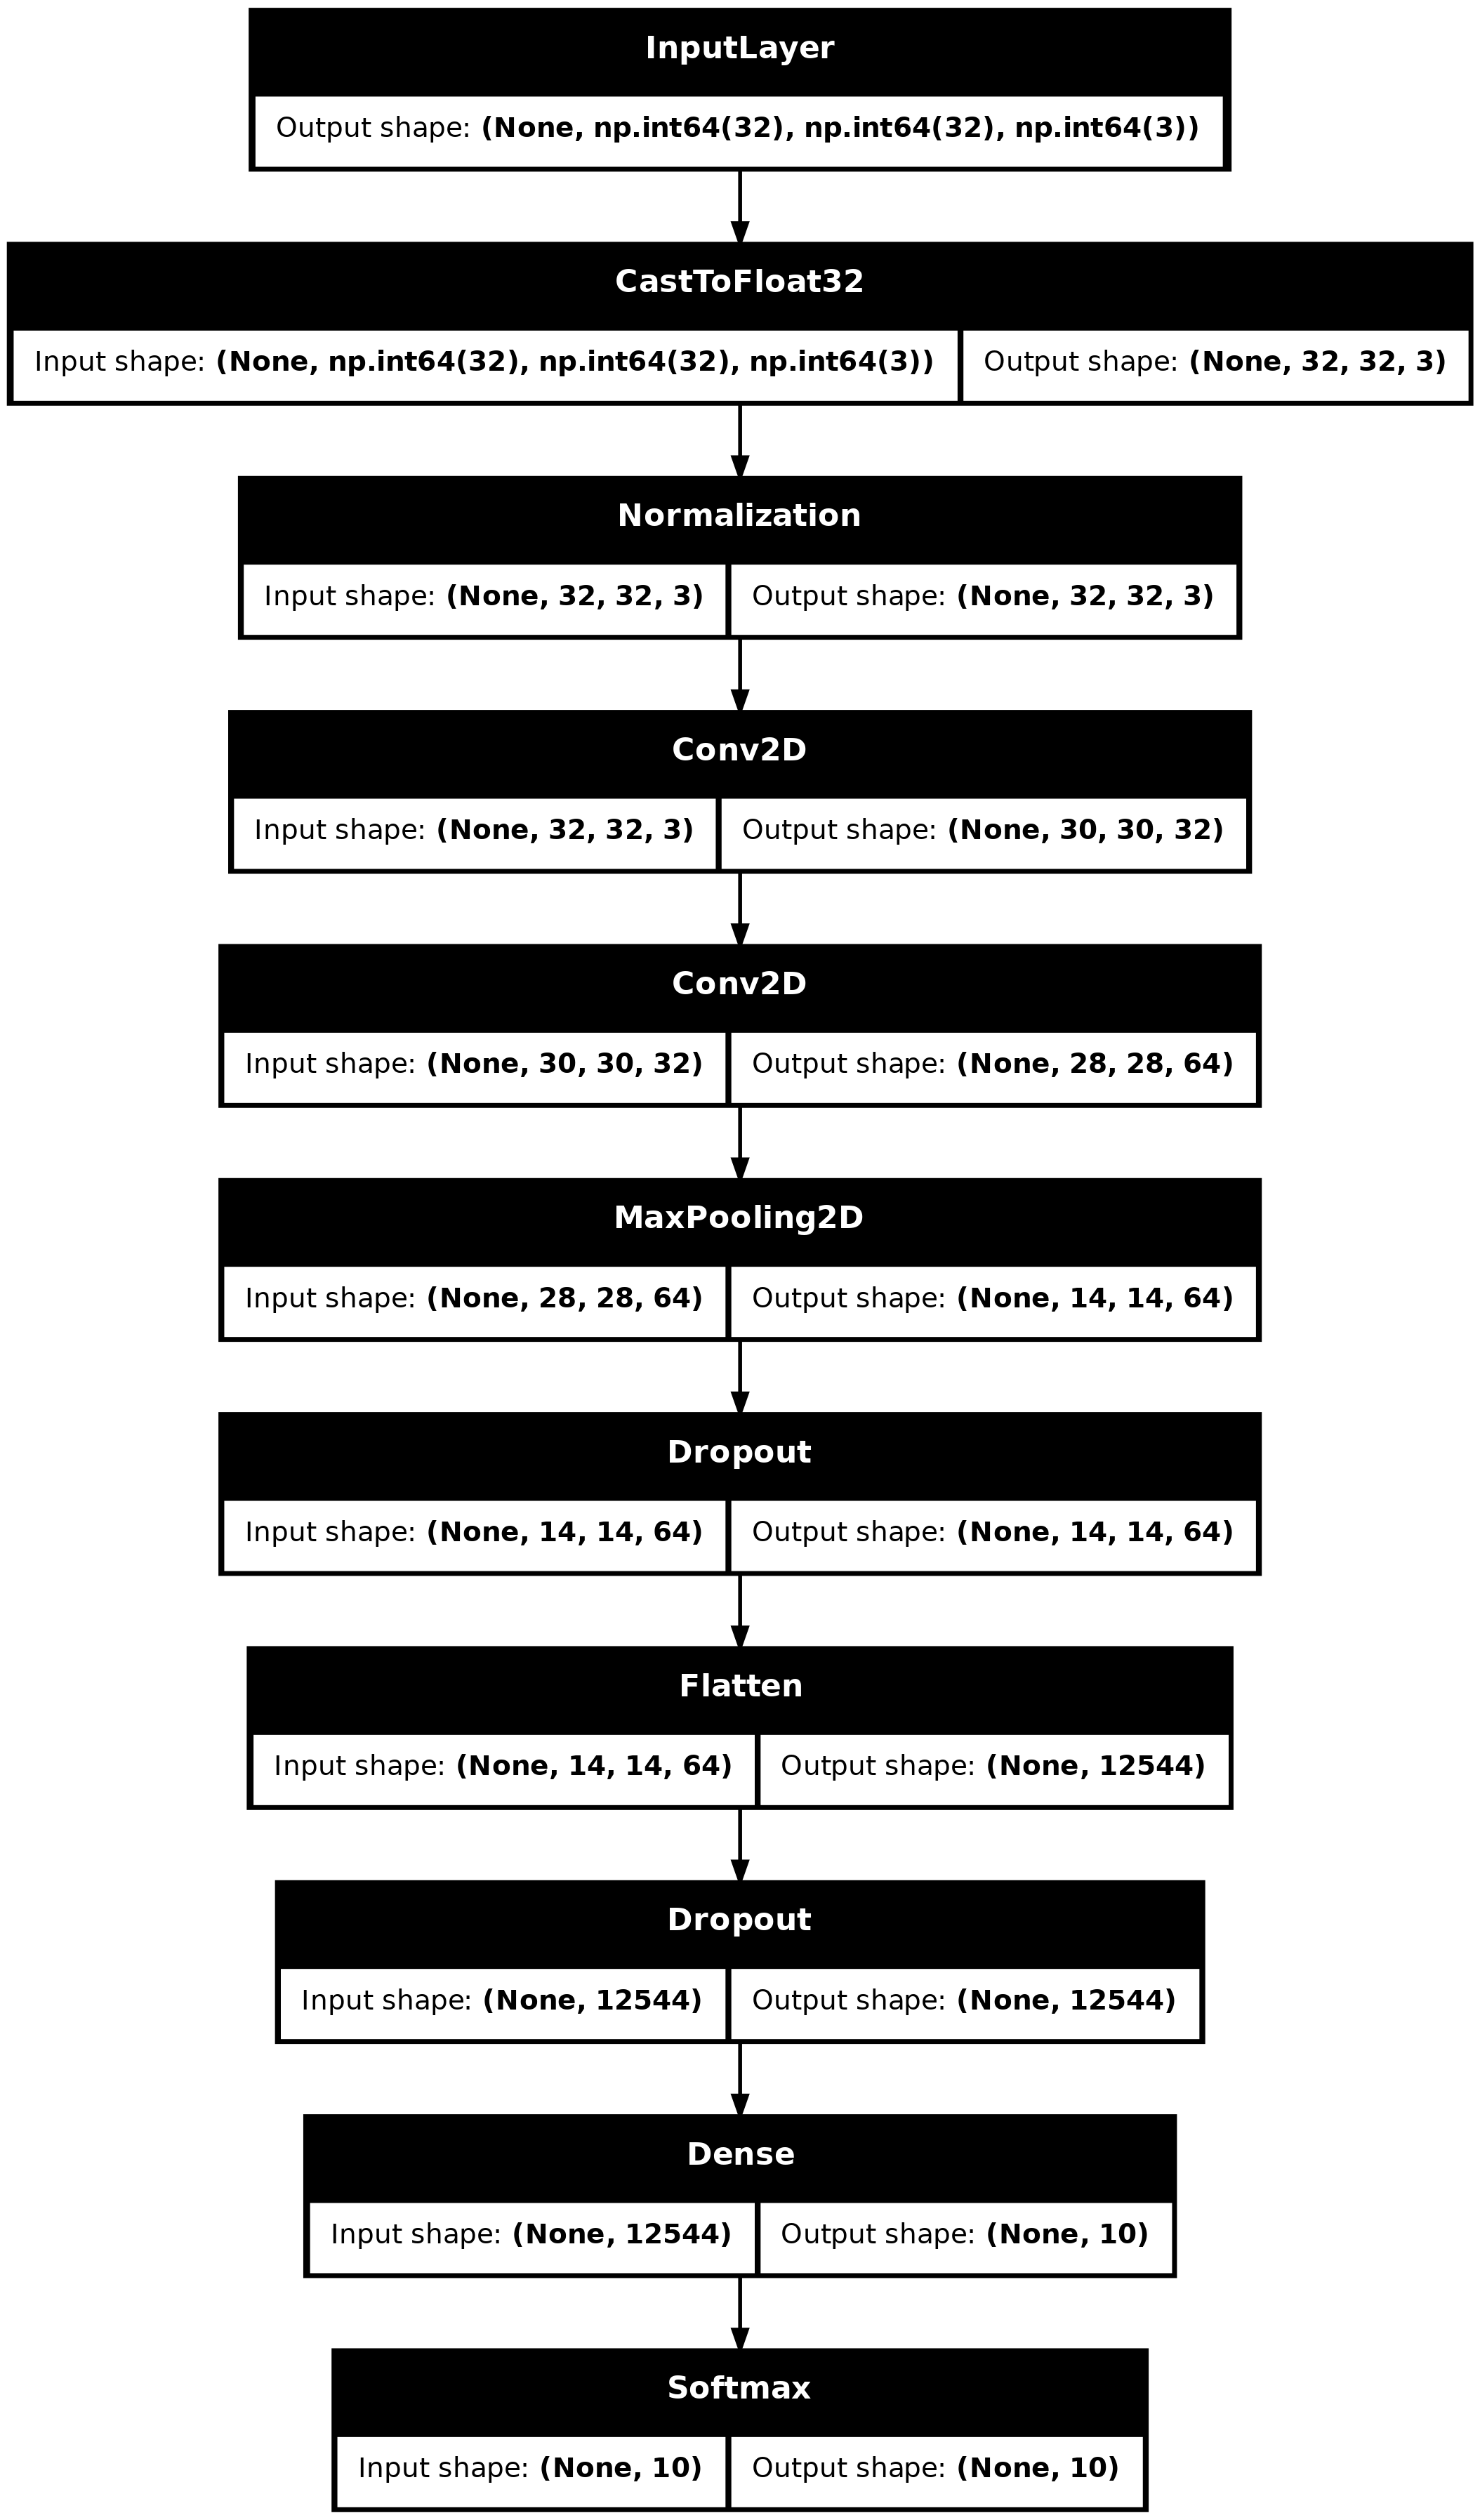

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model ,show_shapes=True)